In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Display dataset information
df.info()

# Display statistical summary
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate rows: 0


In [4]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column because it has too many missing values
df = df.drop(columns=["Cabin"])

# Check if all missing values are handled
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Research Question

What factors affected the survival of passengers on the Titanic?

This analysis aims to answer:

- How did gender influence survival?
- Did passenger class affect survival?
- What was the age distribution of passengers?
- How were passengers distributed based on ticket fare?

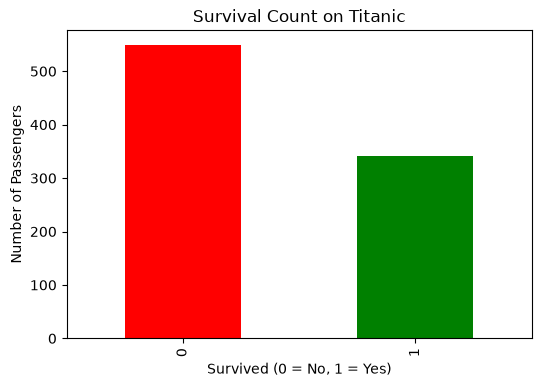

In [5]:
import matplotlib.pyplot as plt

survival_count = df["Survived"].value_counts()

plt.figure(figsize=(6,4))
survival_count.plot(kind="bar", color=["red", "green"])

plt.title("Survival Count on Titanic")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

### Insight

The graph shows that the number of passengers who did not survive was significantly higher than the number of passengers who survived. This indicates that the survival rate on the Titanic was relatively low.

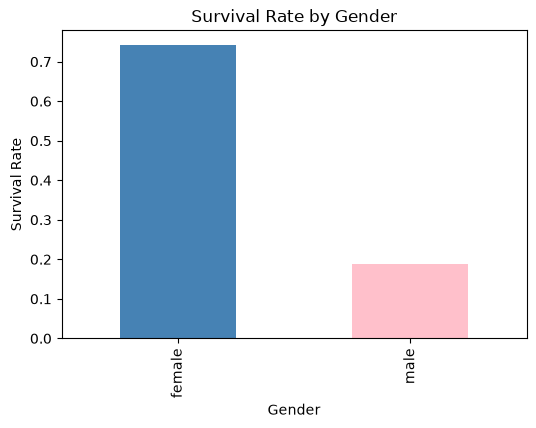

In [6]:
import matplotlib.pyplot as plt

gender_survival = df.groupby("Sex")["Survived"].mean()

plt.figure(figsize=(6,4))
gender_survival.plot(kind="bar", color=["steelblue", "pink"])

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

## Insight

The graph shows that female passengers had a much higher survival rate than male passengers. This suggests that women were given higher priority during the evacuation process.

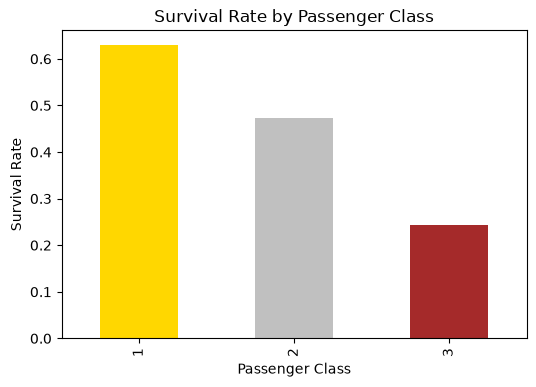

In [7]:
import matplotlib.pyplot as plt

class_survival = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6,4))
class_survival.plot(kind="bar", color=["gold", "silver", "brown"])

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Insight

The graph shows that passengers traveling in First Class had the highest survival rate, followed by Second Class. Third Class passengers had the lowest survival rate, indicating that passenger class had a significant impact on survival.

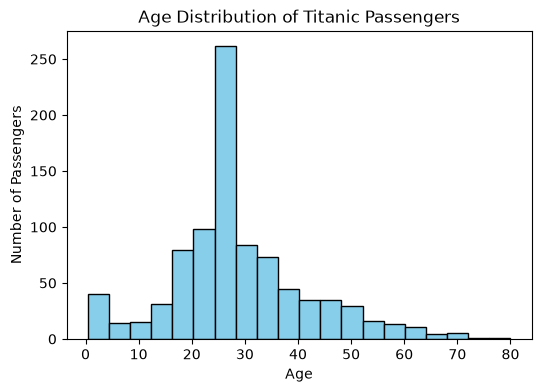

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20, color="skyblue", edgecolor="black")

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Insight

The histogram shows that most Titanic passengers were between 20 and 40 years old. There were fewer children and elderly passengers compared to adults.

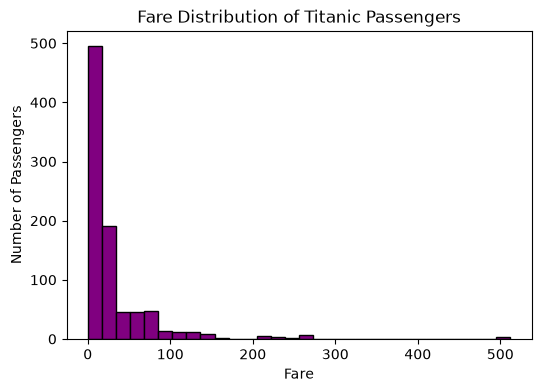

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Fare"], bins=30, color="purple", edgecolor="black")

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

## Insight

The fare distribution is highly skewed. Most passengers paid relatively low fares, while only a few passengers paid very high fares. This indicates that the majority of travelers belonged to lower-priced ticket categories.

# Conclusion

## Key Findings

- More passengers did not survive than survived.
- Female passengers had a much higher survival rate than male passengers.
- First Class passengers had the highest survival rate, while Third Class had the lowest.
- Most passengers were between 20 and 40 years old.
- Most passengers paid relatively low fares, with only a few paying very high fares.

## Overall Insight

This analysis shows that survival on the Titanic was strongly influenced by gender and passenger class. Women and First Class passengers had better chances of survival, while most passengers belonged to the adult age group and traveled with lower-priced tickets.